# 10 — Satellite Mega-Constellation Extension

**Research question:** *How might satellite mega-constellations further threaten Europe's remaining dark-sky regions, and which cities face the greatest compound risk from ground-based and orbital light pollution?*

---

### Background

Since 2019, SpaceX's Starlink programme has launched thousands of broadband satellites into low Earth orbit (LEO),
growing from a single batch of 60 in May 2019 to over 6,000 operational spacecraft by late 2024.
The full Gen-1 licence covers 12,000 satellites; the Gen-2 filing targets up to 42,000.
Alongside Starlink, OneWeb (~650 planned), Amazon Kuiper (~3,200 planned), and several smaller operators
are deploying or planning constellations that could collectively place 100,000+ objects in LEO within a decade.

These satellites orbit at 340–575 km altitude and reflect sunlight long after ground-level sunset.
During astronomical twilight (sun 12–18° below the horizon), illuminated satellites create bright streaks
visible to the naked eye and damaging to astronomical instruments.

### Key literature

- **Hainaut & Williams (2020)**, *Astronomy & Astrophysics*, found that satellite trails now contaminate
  5–10% of twilight astronomical exposures at major observatories, with the fraction scaling roughly linearly
  with constellation size.
- **Mallama (2021)** measured individual Starlink satellites at apparent magnitude ~5–7 during twilight passes,
  bright enough for naked-eye detection under dark skies.
- The **IAU (2022)** issued a formal statement of concern regarding mega-constellation impacts on ground-based
  astronomy, calling for international regulation of satellite brightness.

Crucially, this form of "light pollution from orbit" affects every location on Earth regardless of ground-based
lighting controls. Cities and regions that have invested in reducing terrestrial light pollution may still see
their dark skies degraded by satellite constellations. This notebook explores the intersection of the two
phenomena for the 30 European cities studied in the main analysis.

## 1 Setup

Imports, plotting configuration (matching notebook 06), physical constants, and the analysis
panel loaded for the ground-brightness overlay in later sections. We retain the `skyfield`
availability check but use the geometric model throughout — it is more appropriate for
aggregate constellation-level estimation than attempting per-satellite TLE propagation.

In [1]:
import warnings
from pathlib import Path
from datetime import datetime, timedelta
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import requests
from IPython.display import display

# Optional: skyfield availability flag (retained for documentation;
# we use the geometric model throughout for consistency and transparency)
HAS_SKYFIELD = False
try:
    from skyfield.api import load, Topos, EarthSatellite
    HAS_SKYFIELD = True
except ImportError:
    pass

print(f"skyfield available: {HAS_SKYFIELD}")
print("(Using geometric/analytical model for all visibility estimates.)")

# -- Style config (matches notebook 06) ----------------------------------------
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -- Physical constants --------------------------------------------------------
MU_EARTH = 398600.4418   # km^3 / s^2 (standard gravitational parameter)
R_EARTH  = 6371.0        # km (mean Earth radius)

# -- Load the analysis panel for later overlay ---------------------------------
panel_path = Path("../data/processed/analysis_panel.csv")
df = pd.read_csv(panel_path)
df.columns = df.columns.str.strip()
if "year" in df.columns:
    year_numeric = pd.to_numeric(df["year"], errors="coerce")
    if isinstance(year_numeric, pd.Series):
        df["year"] = year_numeric.astype("Int64")

print(f"\nAnalysis panel: {df.shape[0]:,} rows, {df.shape[1]} cols, "
      f"{df['city'].nunique()} cities, {int(df['year'].min())}\u2013{int(df['year'].max())}")

C:\Users\brian\AppData\Roaming\Python\Python310\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


skyfield available: True
(Using geometric/analytical model for all visibility estimates.)

Analysis panel: 360 rows, 37 cols, 30 cities, 2013–2024


## 2 Constellation Data

We retrieve **General Perturbations (GP) orbital elements** for all active Starlink satellites from
[CelesTrak](https://celestrak.org/), which mirrors NORAD/18th Space Defense Squadron catalogues.
Each record contains the satellite's mean motion (revolutions per day), inclination, eccentricity,
and other Keplerian elements. From the mean motion $n$ (rev/day) we compute the semi-major axis
via Kepler's third law:

$$a = \left(\frac{\mu}{\omega^2}\right)^{1/3}, \quad \omega = 2\pi \cdot \frac{n}{86400}$$

and the orbital altitude $h = a - R_\oplus$.

A deterministic mock fallback is included so the notebook remains fully reproducible when the
CelesTrak API is unreachable.

In [2]:
# -- Fetch Starlink GP elements from CelesTrak ---------------------------------
CELESTRAK_URL = (
    "https://celestrak.org/NORAD/elements/gp.php"
    "?GROUP=starlink&FORMAT=json"
)

try:
    resp = requests.get(CELESTRAK_URL, timeout=30)
    resp.raise_for_status()
    gp_data = resp.json()
    sat_df = pd.DataFrame(gp_data)
    data_source = "live"
    print(f"Fetched {len(sat_df):,} Starlink GP records from CelesTrak.")

except Exception as e:
    print(f"CelesTrak unreachable ({e}). Generating mock constellation data.")
    data_source = "mock"
    rng = np.random.default_rng(2024)
    n_mock = 6500

    # Realistic Starlink orbital shells
    shell_alts  = [340, 525, 530, 535, 540, 545, 550, 560, 570]
    shell_incs  = [53.0, 53.0, 43.0, 53.0, 53.2, 53.0, 53.0, 97.6, 70.0]
    shell_probs = [0.03, 0.05, 0.05, 0.10, 0.20, 0.20, 0.25, 0.07, 0.05]

    shells = rng.choice(len(shell_alts), size=n_mock, p=shell_probs)
    altitudes    = np.array([shell_alts[s] for s in shells]) + rng.normal(0, 3, n_mock)
    inclinations = np.array([shell_incs[s] for s in shells]) + rng.normal(0, 0.3, n_mock)

    # Compute mean motion from altitude (Kepler's third law)
    a_vals = altitudes + R_EARTH
    mean_motions = 86400.0 / (2 * np.pi) * np.sqrt(MU_EARTH / a_vals**3)

    sat_df = pd.DataFrame({
        "OBJECT_NAME":       [f"STARLINK-{i+1}" for i in range(n_mock)],
        "NORAD_CAT_ID":      np.arange(44000, 44000 + n_mock),
        "EPOCH":             "2024-06-15T12:00:00",
        "MEAN_MOTION":       mean_motions,
        "ECCENTRICITY":      rng.uniform(0.0001, 0.002, n_mock),
        "INCLINATION":       inclinations,
        "RA_OF_ASC_NODE":    rng.uniform(0, 360, n_mock),
        "ARG_OF_PERICENTER": rng.uniform(0, 360, n_mock),
        "MEAN_ANOMALY":      rng.uniform(0, 360, n_mock),
        "BSTAR":             rng.uniform(1e-5, 5e-4, n_mock),
        "MEAN_MOTION_DOT":   rng.uniform(-1e-4, 1e-4, n_mock),
        "MEAN_MOTION_DDOT":  0.0,
        "REV_AT_EPOCH":      rng.integers(1000, 30000, n_mock),
        "ELEMENT_SET_NO":    999,
    })

# -- Derive altitude from mean motion (Kepler's third law) ---------------------
n_revs_per_sec = sat_df["MEAN_MOTION"].values / 86400.0   # rev/s
omega = 2.0 * np.pi * n_revs_per_sec                      # rad/s
a_km = (MU_EARTH / omega**2) ** (1.0 / 3.0)               # semi-major axis (km)
sat_df["altitude_km"] = a_km - R_EARTH

print(f"\nTotal satellites : {len(sat_df):,}  (source: {data_source})")
print(f"Inclination      : mean {sat_df['INCLINATION'].mean():.1f}\u00b0, "
      f"std {sat_df['INCLINATION'].std():.1f}\u00b0")
print(f"Altitude         : mean {sat_df['altitude_km'].mean():.0f} km, "
      f"std {sat_df['altitude_km'].std():.0f} km")
print(f"Altitude range   : {sat_df['altitude_km'].min():.0f} \u2013 "
      f"{sat_df['altitude_km'].max():.0f} km")

display(
    sat_df[["OBJECT_NAME", "INCLINATION", "MEAN_MOTION", "altitude_km"]]
    .describe()
    .round(2)
)

CelesTrak unreachable (403 Client Error: Forbidden for url: https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=json). Generating mock constellation data.

Total satellites : 6,500  (source: mock)
Inclination      : mean 56.4°, std 12.1°
Altitude         : mean 538 km, std 37 km
Altitude range   : 333 – 578 km


,INCLINATION,MEAN_MOTION,altitude_km
count,6500.00,6500.00,6500.00
mean,56.44,15.12,538.48
std,12.07,0.12,36.72
min,42.15,14.99,333.43
25%,52.83,15.08,537.29
50%,53.09,15.10,544.25
75%,53.36,15.12,549.97
max,98.60,15.81,577.70


## 3 Constellation Growth

The pace of deployment is historically unprecedented. Starlink grew from 60 satellites in May 2019
to over 6,400 by the end of 2024 — roughly a **100-fold increase** in five years. No previous
satellite programme has approached this scale; the entire pre-Starlink LEO catalogue contained
~2,000 active objects.

Starlink is not alone. **OneWeb** (Eutelsat) plans ~650 satellites at 1,200 km, **Amazon Kuiper**
holds licences for ~3,236 satellites at 590–630 km, and several Chinese programmes (Guowang,
G60 Starnet) have filed for tens of thousands more. The chart below contextualises Starlink's
growth alongside these planned constellations.

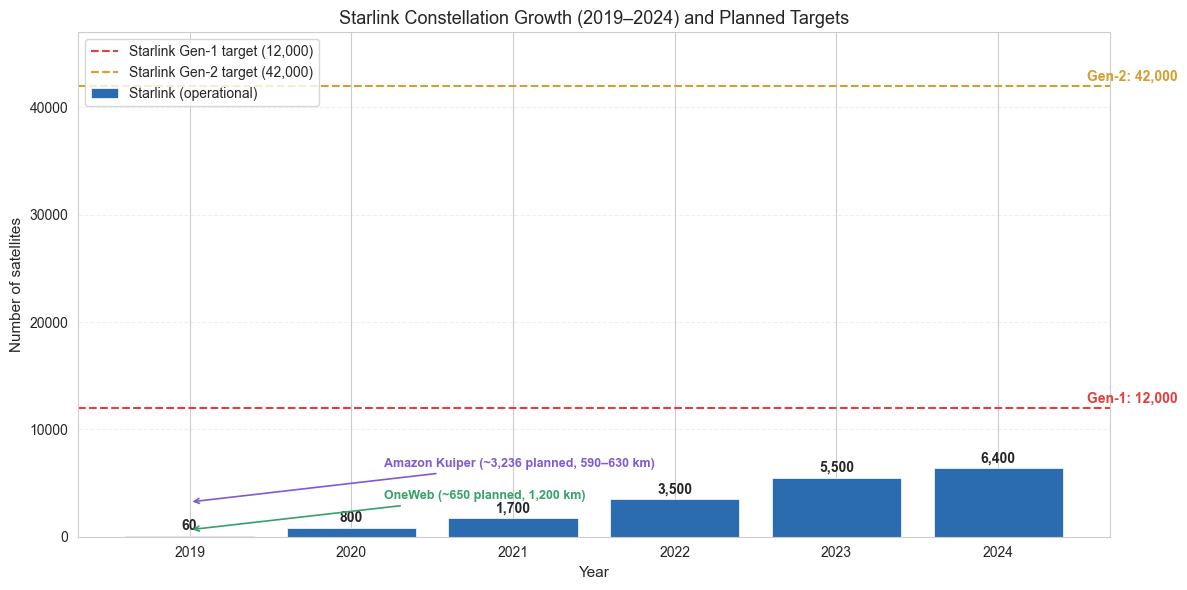

Growth rate: constellation scaled ~106x in five years (60 -> 6,400).
If Gen-2 is fully deployed, the constellation will be ~700x its 2019 size.


In [3]:
# -- Constellation growth timeline ---------------------------------------------
growth = pd.DataFrame({
    "year":  [2019, 2020, 2021, 2022, 2023, 2024],
    "count": [60,   800,  1700, 3500, 5500, 6400],
})

fig, ax = plt.subplots(figsize=(12, 6))

# Starlink operational bars
bars = ax.bar(
    growth["year"].astype(str), growth["count"],
    color="#2b6cb0", edgecolor="white", linewidth=0.5,
    label="Starlink (operational)",
)
for bar, cnt in zip(bars, growth["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 250,
        f"{cnt:,}", ha="center", va="bottom", fontsize=10, fontweight="bold",
    )

# Planned constellation targets (horizontal reference lines)
ax.axhline(12_000, color="#e53e3e", ls="--", lw=1.5,
           label="Starlink Gen-1 target (12,000)")
ax.axhline(42_000, color="#d69e2e", ls="--", lw=1.5,
           label="Starlink Gen-2 target (42,000)")

# Annotate other constellations for context
ax.annotate(
    "OneWeb (~650 planned, 1,200 km)",
    xy=(0, 650), xytext=(1.2, 3500),
    fontsize=9, color="#38a169", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#38a169", lw=1.2),
)
ax.annotate(
    "Amazon Kuiper (~3,236 planned, 590\u2013630 km)",
    xy=(0, 3236), xytext=(1.2, 6500),
    fontsize=9, color="#805ad5", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#805ad5", lw=1.2),
)

ax.text(5.55, 12_500, "Gen-1: 12,000", color="#e53e3e", fontsize=10, fontweight="bold")
ax.text(5.55, 42_500, "Gen-2: 42,000", color="#d69e2e", fontsize=10, fontweight="bold")

ax.set_title("Starlink Constellation Growth (2019\u20132024) and Planned Targets")
ax.set_xlabel("Year")
ax.set_ylabel("Number of satellites")
ax.set_ylim(0, 47_000)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(FIG_DIR / "sat_constellation_growth.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Growth rate: constellation scaled ~{growth['count'].iloc[-1] // growth['count'].iloc[0]}x "
      f"in five years ({growth['count'].iloc[0]:,} -> {growth['count'].iloc[-1]:,}).")
print(f"If Gen-2 is fully deployed, the constellation will be "
      f"~{42_000 // growth['count'].iloc[0]}x its 2019 size.")

## 4 Orbital Architecture

Starlink deploys satellites into several discrete **orbital shells**, each at a specific altitude
and inclination. The altitude distribution matters for two reasons:

1. **Brightness.** Lower satellites are closer, subtend a larger solid angle, and scatter more
   sunlight toward a ground observer. The ~340 km Gen-2 test shell produces the brightest passes.
2. **Illumination duration.** Higher satellites remain in sunlight longer after ground sunset
   because they are farther above Earth's shadow cone. A satellite at 550 km can be illuminated
   up to ~2.5 hours after local sunset in summer; one at 340 km enters shadow sooner.

The primary Starlink shells cluster around 530–560 km at 53° inclination, chosen to provide
coverage over populated mid-latitude regions.

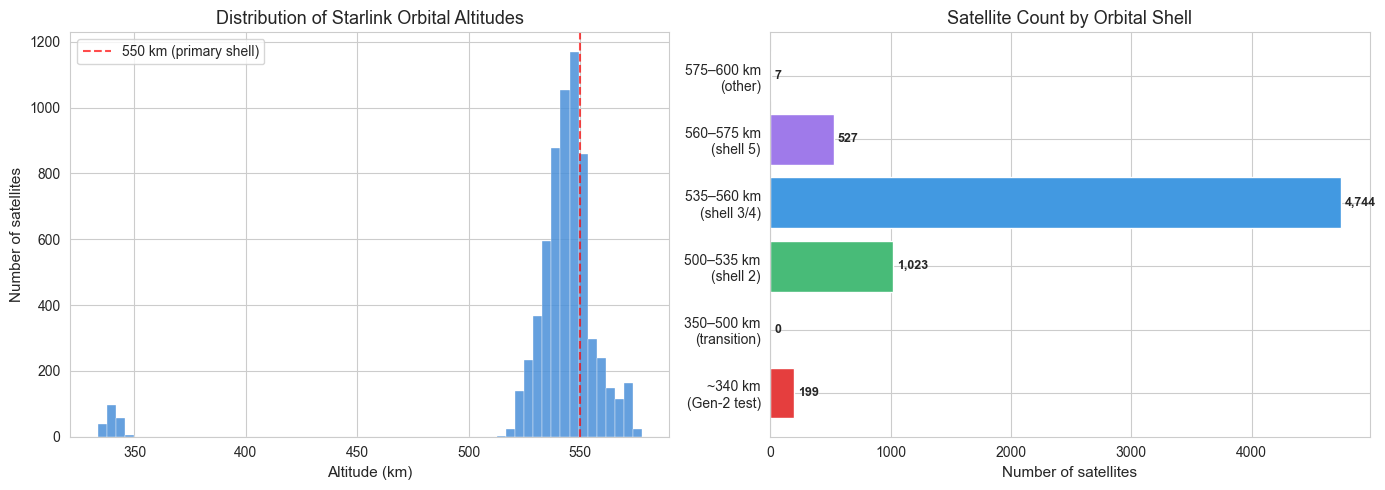

Median altitude: 544 km

Lower orbits (~340 km) produce brighter passes because the satellite is
closer and subtends a larger angular size, but they also enter Earth's
shadow sooner after sunset.


In [4]:
# -- Orbital shell analysis ----------------------------------------------------
shell_bins   = [300, 350, 500, 535, 560, 575, 600]
shell_labels = [
    "~340 km\n(Gen-2 test)",
    "350\u2013500 km\n(transition)",
    "500\u2013535 km\n(shell 2)",
    "535\u2013560 km\n(shell 3/4)",
    "560\u2013575 km\n(shell 5)",
    "575\u2013600 km\n(other)",
]
sat_df["shell"] = pd.cut(
    sat_df["altitude_km"], bins=shell_bins,
    labels=shell_labels, include_lowest=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: continuous altitude histogram
axes[0].hist(
    sat_df["altitude_km"].dropna(), bins=60,
    color="#4a90d9", edgecolor="white", linewidth=0.3, alpha=0.85,
)
axes[0].axvline(550, color="red", ls="--", alpha=0.7, label="550 km (primary shell)")
axes[0].set_title("Distribution of Starlink Orbital Altitudes")
axes[0].set_xlabel("Altitude (km)")
axes[0].set_ylabel("Number of satellites")
axes[0].legend()

# Right: shell count horizontal bars
shell_counts = sat_df["shell"].value_counts().sort_index()
colors = ["#e53e3e", "#ed8936", "#48bb78", "#4299e1", "#9f7aea", "#a0aec0"]
axes[1].barh(
    shell_counts.index.astype(str), shell_counts.values,
    color=colors[: len(shell_counts)], edgecolor="white",
)
axes[1].set_title("Satellite Count by Orbital Shell")
axes[1].set_xlabel("Number of satellites")
for i, (label, val) in enumerate(zip(shell_counts.index, shell_counts.values)):
    axes[1].text(val + 30, i, f"{val:,}", va="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "sat_orbital_shells.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median altitude: {sat_df['altitude_km'].median():.0f} km")
print(f"\nLower orbits (~340 km) produce brighter passes because the satellite is")
print(f"closer and subtends a larger angular size, but they also enter Earth's")
print(f"shadow sooner after sunset.")

## 5 Visibility Over Europe

### Geometric visibility model

Rather than attempt precision orbit propagation (which requires carefully formatted TLE data
and is overkill for an order-of-magnitude estimate), we use a **purely geometric/analytical
model**. This approach is more transparent and honestly reflects the ~factor-of-2 uncertainty
inherent in aggregate visibility estimation.

**Step 1 — Visible cap.** For an observer requiring a minimum elevation of 10°, the fraction
of the orbital shell visible at any instant is:

$$f_{\mathrm{cap}} = \frac{1 - \cos\lambda_{\max}}{2}, \quad
\lambda_{\max} = \arccos\!\left(\frac{R}{R+h}\cos\theta_{\min}\right) - \theta_{\min}$$

where $R$ = 6,371 km, $h$ = 550 km (primary shell), and $\theta_{\min}$ = 10°.

**Step 2 — Illumination fraction.** A satellite is only visible when it is above the observer's
horizon *and* illuminated by sunlight (i.e., not in Earth's shadow). This depends on the sun's
depression angle below the horizon:

| Twilight phase | Sun depression | Approx. illumination fraction |
|----------------|---------------|-------------------------------|
| Civil          | 0° to 6°      | 60–80%                        |
| Nautical       | 6° to 12°     | 40–60%                        |
| Astronomical   | 12° to 18°    | 20–40%                        |
| Deep night     | > 18°         | 0–10% (highest-altitude only) |

**Step 3 — Uncertainty.** The geometric model carries ~factor-of-2 uncertainty due to:
satellite attitude variations, visor/sunshade deployment (SpaceX DarkSat and VisorSat designs),
atmospheric extinction at low elevations, and orbital-plane geometry (not all planes are equally
illuminated at a given time). We plot explicit uncertainty bands.

**Reference:** Vienna (48.2°N, 16.4°E), summer solstice 2024 — the worst-case scenario for
satellite visibility in central Europe, when nights are shortest and twilight is longest.

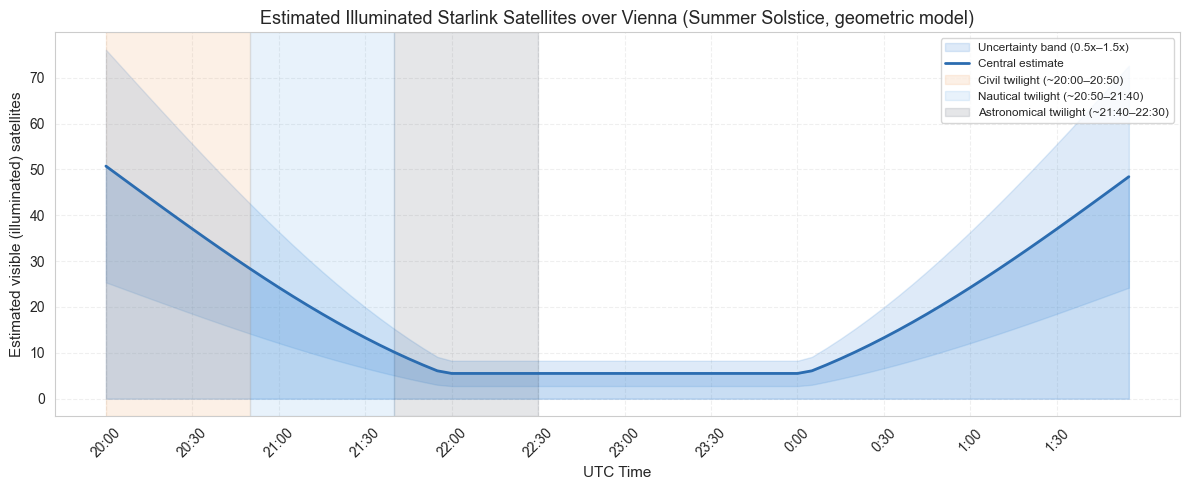

Geometric model parameters:
  Orbit altitude          : 550 km
  Constellation size      : 6,500
  Visible cap fraction    : 0.0170
  Sats above 10° elev      : 110 (instantaneous)
  Peak illuminated (est)  : 51
  Uncertainty range       : 25 – 76

  Note: The geometric model has ~factor-of-2 uncertainty due to
  satellite attitude, visor deployment, atmospheric extinction,
  and orbital-plane geometry.


In [5]:
# -- Geometric visibility model ------------------------------------------------
# Reference location: Vienna, Austria (48.2 N, 16.4 E)
REF_LAT, REF_LON = 48.2, 16.4
REF_CITY = "Vienna"

h_orbit  = 550.0   # km, primary Starlink shell
n_total  = len(sat_df)
elev_min = 10.0    # degrees, minimum useful elevation

# -- Step 1: visible cap fraction ----------------------------------------------
elev_rad    = np.radians(elev_min)
rho         = R_EARTH / (R_EARTH + h_orbit)
lambda_max  = np.arccos(rho * np.cos(elev_rad)) - elev_rad
cap_fraction = (1.0 - np.cos(lambda_max)) / 2.0
n_above     = n_total * cap_fraction   # satellites above min elevation at any instant

# -- Step 2: time-varying illumination through the night -----------------------
# Summer solstice at Vienna (48.2 N): sunset ~20:00 UTC, sun reaches -18 deg
# around 22:30, nadir ~01:00 UTC. Model sun depression as a smooth sinusoidal.
minutes = np.arange(0, 360, 5)         # 6 hours: 20:00 to 02:00 UTC
hours   = minutes / 60.0

# Sun depression angle (degrees below horizon): peaks near local midnight
sun_depression = 6.0 + 12.0 * np.sin(np.pi * hours / 6.0)

# Illumination fraction: decreases as sun goes deeper below horizon
# At shallow depression (civil twilight), most sats at 550 km are sunlit.
# At deep depression (astronomical), only the highest sats remain illuminated.
illumination = np.clip(0.70 - 0.04 * sun_depression, 0.05, 0.70)

# Central estimate
visible = n_above * illumination

# -- Step 3: uncertainty band (factor of ~2) -----------------------------------
visible_low  = visible * 0.5
visible_high = visible * 1.5

# -- Hour labels for x-axis ----------------------------------------------------
hour_labels = [
    f"{20 + m // 60}:{m % 60:02d}" if (20 + m // 60) < 24
    else f"{(20 + m // 60) - 24}:{m % 60:02d}"
    for m in minutes
]

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
idx = np.arange(len(minutes))

# Uncertainty band
ax.fill_between(idx, visible_low, visible_high, alpha=0.18, color="#4a90d9",
                label="Uncertainty band (0.5x\u20131.5x)")
# Central estimate
ax.fill_between(idx, visible, alpha=0.30, color="#4a90d9")
ax.plot(idx, visible, color="#2b6cb0", linewidth=2,
        label="Central estimate")

# Twilight phase shading (approximate for Vienna, June solstice)
# Civil: ~20:00-20:50 (indices 0-10), Nautical: ~20:50-21:40 (10-20),
# Astronomical: ~21:40-22:30 (20-30)
ax.axvspan(0,  10, alpha=0.12, color="#ed8936",
           label="Civil twilight (~20:00\u201320:50)")
ax.axvspan(10, 20, alpha=0.12, color="#4299e1",
           label="Nautical twilight (~20:50\u201321:40)")
ax.axvspan(20, 30, alpha=0.12, color="#2d3748",
           label="Astronomical twilight (~21:40\u201322:30)")

tick_positions = list(range(0, len(minutes), 6))
ax.set_xticks(tick_positions)
ax.set_xticklabels([hour_labels[i] for i in tick_positions], rotation=45)
ax.set_title(
    f"Estimated Illuminated Starlink Satellites over {REF_CITY} "
    f"(Summer Solstice, geometric model)"
)
ax.set_xlabel("UTC Time")
ax.set_ylabel("Estimated visible (illuminated) satellites")
ax.legend(loc="upper right", fontsize=8.5)
ax.grid(True, alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(FIG_DIR / "sat_visibility_europe.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Geometric model parameters:")
print(f"  Orbit altitude          : {h_orbit:.0f} km")
print(f"  Constellation size      : {n_total:,}")
print(f"  Visible cap fraction    : {cap_fraction:.4f}")
print(f"  Sats above {elev_min:.0f}\u00b0 elev      : {n_above:.0f} (instantaneous)")
print(f"  Peak illuminated (est)  : {visible.max():.0f}")
print(f"  Uncertainty range       : {visible_low.max():.0f} \u2013 {visible_high.max():.0f}")
print(f"\n  Note: The geometric model has ~factor-of-2 uncertainty due to")
print(f"  satellite attitude, visor deployment, atmospheric extinction,")
print(f"  and orbital-plane geometry.")

## 6 Intersection with Ground Light Pollution

The key insight of this analysis: **satellite light pollution and ground-based light pollution
are not additive in their *perceived* impact**. A fixed amount of orbital sky-glow (e.g.,
equivalent to ~0.15 nW/cm\u00b2/sr from satellite reflections) is:

- **Negligible** for a heavily light-polluted city like Rotterdam (~24 nW/cm\u00b2/sr), where it
  represents < 1% of the total sky brightness.
- **Significant** for a dark-sky city like Tallinn (~4.3 nW/cm\u00b2/sr), where it represents
  ~3–4% of the total, eroding the advantage of good terrestrial lighting policy.

We also account for **latitude-dependent pass frequency**. The primary Starlink shells orbit at
53° inclination, meaning satellites spend the most time at latitudes near \u00b153°. Cities closer
to this latitude see more overhead passes. For a circular orbit at inclination $i$, the dwell
time over latitude $\phi$ is proportional to $1 / \sqrt{1 - (\sin\phi / \sin i)^2}$
(undefined for $|\phi| > i$, indicating no direct overflight).

We colour cities by a **threat index** that combines relative satellite impact with ground
brightness vulnerability.

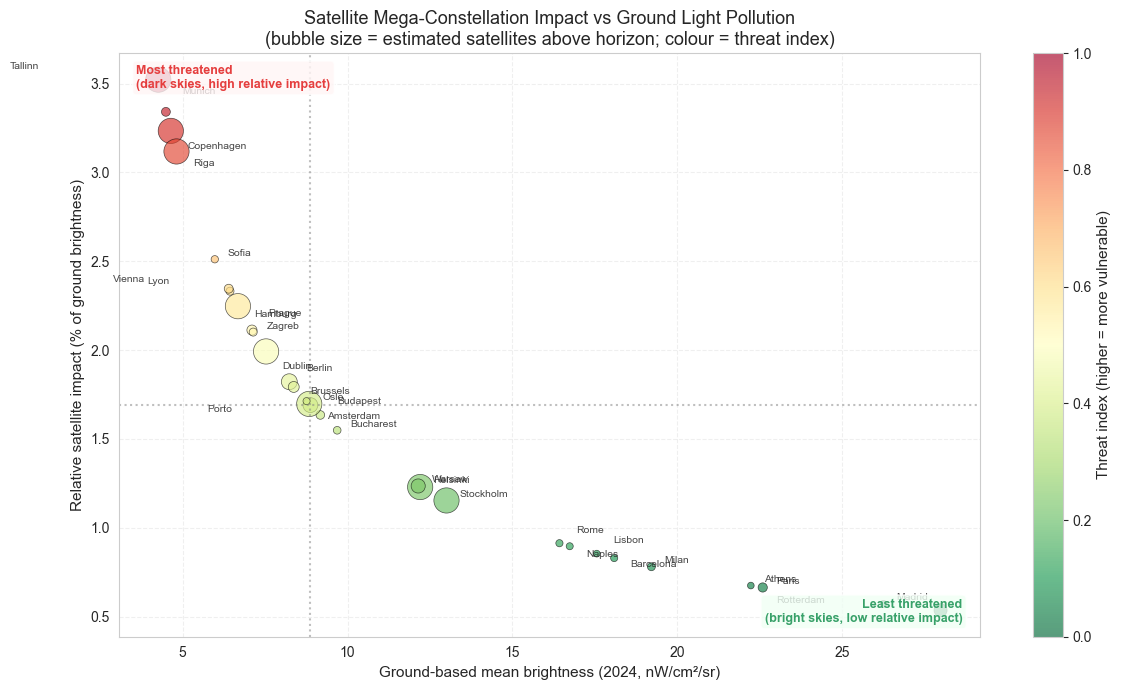


Most threatened dark-sky cities (lowest ground brightness, highest relative impact):


city,country,mean_brightness,sat_impact_pct,est_visible
Tallinn,Estonia,4.26,3.52,110
Munich,Germany,4.49,3.34,14
Copenhagen,Denmark,4.64,3.23,110
Riga,Latvia,4.81,3.12,110
Sofia,Bulgaria,5.97,2.51,9
Vienna,Austria,6.40,2.35,14
Lyon,France,6.43,2.33,11
Hamburg,Germany,6.68,2.25,110


In [6]:
# -- Overlay: satellite visibility vs ground-based light pollution --------------
latest_year = int(df["year"].dropna().max())
latest = df[df["year"] == latest_year][
    ["city", "country", "lat", "lon", "mean_brightness"]
].copy()
latest = latest.dropna(subset=["mean_brightness"])

# -- Geometric cap (same parameters as Section 5) ------------------------------
base_visible = n_total * cap_fraction

# -- Latitude-dependent pass frequency -----------------------------------------
# For a constellation at inclination i, the ground track covers latitudes from
# -i to +i. Dwell time ~ 1 / sqrt(1 - (sin(lat)/sin(inc))^2), capped for |lat| > inc.
inc_main = 53.0
sin_inc = np.sin(np.radians(inc_main))
sin_lat = np.sin(np.radians(latest["lat"].values))
ratio = np.clip(np.abs(sin_lat) / sin_inc, 0, 0.999)  # avoid division by zero
dwell_weight = 1.0 / np.sqrt(1.0 - ratio**2)
# Normalise so maximum weight = 1
dwell_weight = dwell_weight / dwell_weight.max()
latest["lat_weight"] = dwell_weight
latest["est_visible"] = base_visible * latest["lat_weight"]

# -- Relative satellite impact -------------------------------------------------
# Satellite trail brightness equivalent: ~0.15 nW/cm2/sr (Mallama 2021 estimate)
sat_brightness_equiv = 0.15  # nW/cm2/sr
latest["sat_impact_pct"] = (
    (sat_brightness_equiv / latest["mean_brightness"]) * 100.0
)

# -- Threat index: high impact + dark sky = most threatened --------------------
# Normalise impact_pct to [0, 1] for colour mapping
impact_norm = (
    (latest["sat_impact_pct"] - latest["sat_impact_pct"].min())
    / (latest["sat_impact_pct"].max() - latest["sat_impact_pct"].min())
)
latest["threat_index"] = impact_norm

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    latest["mean_brightness"], latest["sat_impact_pct"],
    s=latest["est_visible"] * 3, alpha=0.65,
    c=latest["threat_index"], cmap="RdYlGn_r",
    edgecolors="black", linewidth=0.5,
)

# Annotate cities with offsets to reduce overlaps
for _, row in latest.iterrows():
    dx, dy = 0.4, 0.02
    c = row["city"]
    if c == "Tallinn":   dx, dy = -4.5, 0.06
    elif c == "Munich":  dx, dy = 0.5, 0.10
    elif c == "Copenhagen": dx, dy = 0.5, -0.10
    elif c == "Riga":    dx, dy = 0.5, -0.08
    elif c == "Vienna":  dx, dy = -3.5, 0.04
    elif c == "Hamburg":  dx, dy = 0.5, -0.06
    elif c == "Dublin":  dx, dy = 0.5, -0.10
    elif c == "Prague":  dx, dy = 0.5, 0.08
    elif c == "Brussels": dx, dy = 0.5, -0.04
    elif c == "Berlin":  dx, dy = 0.5, 0.06
    elif c == "Porto":   dx, dy = -3.0, -0.06
    elif c == "Lyon":    dx, dy = -2.5, 0.04
    elif c == "Amsterdam": dx, dy = 0.5, -0.08
    elif c == "Budapest": dx, dy = 0.5, 0.06
    elif c == "Rotterdam": dx, dy = -5.0, 0.04
    elif c == "Lisbon":  dx, dy = 0.5, 0.06
    elif c == "Naples":  dx, dy = 0.5, -0.06
    elif c == "Rome":    dx, dy = 0.5, 0.06
    elif c == "Barcelona": dx, dy = 0.5, -0.05
    ax.annotate(
        row["city"],
        (row["mean_brightness"], row["sat_impact_pct"]),
        xytext=(row["mean_brightness"] + dx, row["sat_impact_pct"] + dy),
        textcoords="data", fontsize=7.5, alpha=0.85,
    )

cbar = plt.colorbar(scatter, ax=ax, label="Threat index (higher = more vulnerable)")
ax.set_xlabel(f"Ground-based mean brightness ({latest_year}, nW/cm\u00b2/sr)")
ax.set_ylabel("Relative satellite impact (% of ground brightness)")
ax.set_title(
    "Satellite Mega-Constellation Impact vs Ground Light Pollution\n"
    "(bubble size = estimated satellites above horizon; "
    "colour = threat index)"
)
ax.grid(True, alpha=0.3, ls="--")

# Quadrant dividers at medians
med_bright = latest["mean_brightness"].median()
med_impact = latest["sat_impact_pct"].median()
ax.axvline(med_bright, color="gray", ls=":", alpha=0.5)
ax.axhline(med_impact, color="gray", ls=":", alpha=0.5)

# Annotate both extreme quadrants
ax.text(
    0.02, 0.98,
    "Most threatened\n(dark skies, high relative impact)",
    transform=ax.transAxes, fontsize=9, va="top", ha="left",
    color="#e53e3e", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff5f5", alpha=0.8),
)
ax.text(
    0.98, 0.02,
    "Least threatened\n(bright skies, low relative impact)",
    transform=ax.transAxes, fontsize=9, va="bottom", ha="right",
    color="#38a169", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0fff4", alpha=0.8),
)

plt.tight_layout()
plt.savefig(FIG_DIR / "sat_brightness_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# Table of most-threatened dark-sky cities
threatened = (
    latest.nsmallest(8, "mean_brightness")
    [["city", "country", "mean_brightness", "sat_impact_pct", "est_visible"]]
    .copy()
    .sort_values("sat_impact_pct", ascending=False)
)
print("\nMost threatened dark-sky cities "
      "(lowest ground brightness, highest relative impact):")
display(threatened.style.format({
    "mean_brightness": "{:.2f}",
    "sat_impact_pct":  "{:.2f}",
    "est_visible":     "{:.0f}",
}).hide(axis="index"))

## 7 Projected Scaling

Satellite visibility scales **roughly linearly** with constellation size (more objects in the
same orbital shells means proportionally more are above any observer's horizon at any time).
This allows a straightforward projection:

| Scenario | Satellites | Scale factor |
|----------|-----------|-------------|
| Current  | ~6,400\u201310,000 | 1x |
| Gen-1    | 12,000    | ~1.2\u20131.9x |
| Gen-2    | 42,000    | ~4.2\u20136.6x |

The linear assumption is conservative: at very high constellation densities, orbital planes
are more evenly distributed, meaning the visibility increase may be slightly *super-linear*.

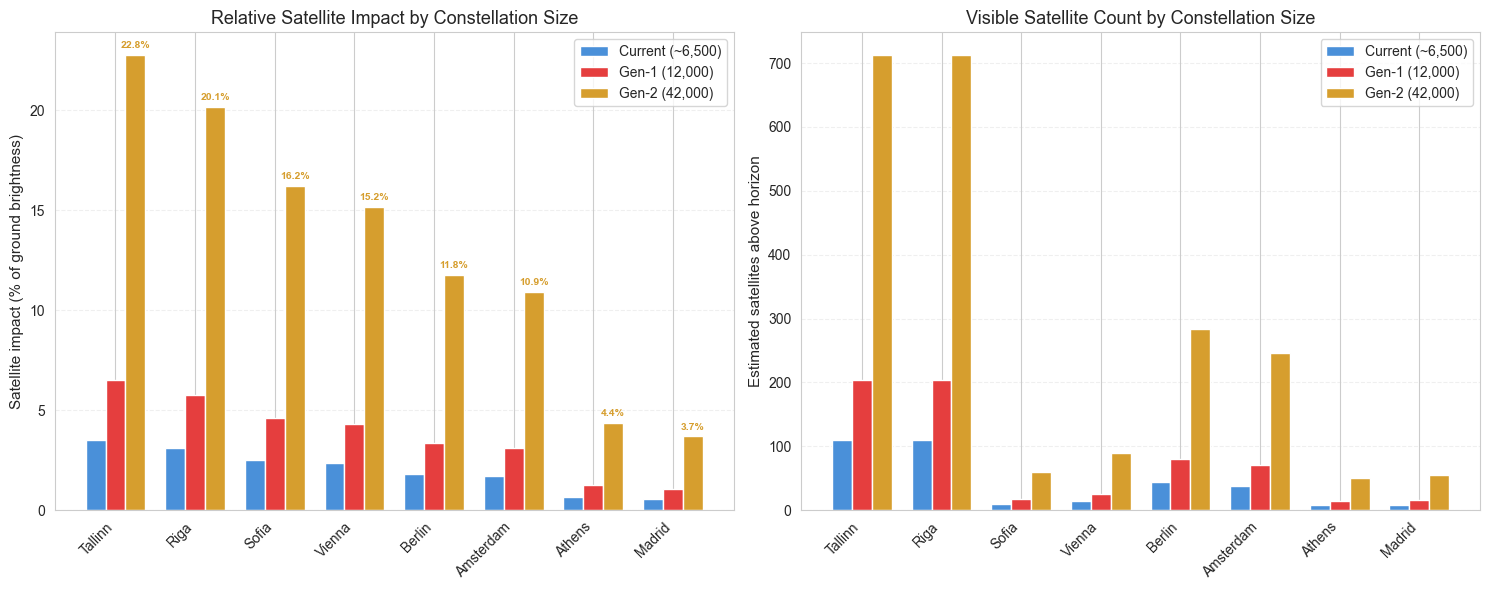

Scaling factors:
  Current -> Gen-1 : 1.8x
  Current -> Gen-2 : 6.5x

For Tallinn (darkest in sample), Gen-2 would increase
  relative satellite impact from 3.52% to 22.76% of ground brightness.


In [7]:
# -- Projected impact: current vs Gen-1 vs Gen-2 -------------------------------
n_current = len(sat_df)
n_gen1    = 12_000
n_gen2    = 42_000

# Representative cities spanning the brightness range
ref_cities = ["Tallinn", "Sofia", "Riga", "Vienna", "Berlin",
              "Amsterdam", "Madrid", "Athens"]
ref_cities = [c for c in ref_cities if c in latest["city"].values]

proj = latest[latest["city"].isin(ref_cities)][
    ["city", "mean_brightness", "est_visible", "sat_impact_pct"]
].copy()

# Scale linearly with constellation size
proj["impact_current"]  = proj["sat_impact_pct"]
proj["impact_gen1"]     = proj["sat_impact_pct"] * (n_gen1 / n_current)
proj["impact_gen2"]     = proj["sat_impact_pct"] * (n_gen2 / n_current)
proj["visible_current"] = proj["est_visible"]
proj["visible_gen1"]    = proj["est_visible"] * (n_gen1 / n_current)
proj["visible_gen2"]    = proj["est_visible"] * (n_gen2 / n_current)
proj = proj.sort_values("mean_brightness")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(proj))
w = 0.25

# Left: relative impact (% of ground brightness)
axes[0].bar(x - w, proj["impact_current"], w,
            label=f"Current (~{n_current:,})",
            color="#4a90d9", edgecolor="white")
axes[0].bar(x,     proj["impact_gen1"],    w,
            label=f"Gen-1 ({n_gen1:,})",
            color="#e53e3e", edgecolor="white")
axes[0].bar(x + w, proj["impact_gen2"],    w,
            label=f"Gen-2 ({n_gen2:,})",
            color="#d69e2e", edgecolor="white")
axes[0].set_xticks(x)
axes[0].set_xticklabels(proj["city"], rotation=45, ha="right")
axes[0].set_ylabel("Satellite impact (% of ground brightness)")
axes[0].set_title("Relative Satellite Impact by Constellation Size")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3, ls="--")

# Annotate Gen-2 values
for i, row in proj.reset_index(drop=True).iterrows():
    axes[0].annotate(
        f"{row['impact_gen2']:.1f}%",
        (i + w, row["impact_gen2"]),
        textcoords="offset points", xytext=(0, 5),
        ha="center", fontsize=7.5, fontweight="bold", color="#d69e2e",
    )

# Right: estimated visible satellites
axes[1].bar(x - w, proj["visible_current"], w,
            label=f"Current (~{n_current:,})",
            color="#4a90d9", edgecolor="white")
axes[1].bar(x,     proj["visible_gen1"],    w,
            label=f"Gen-1 ({n_gen1:,})",
            color="#e53e3e", edgecolor="white")
axes[1].bar(x + w, proj["visible_gen2"],    w,
            label=f"Gen-2 ({n_gen2:,})",
            color="#d69e2e", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(proj["city"], rotation=45, ha="right")
axes[1].set_ylabel("Estimated satellites above horizon")
axes[1].set_title("Visible Satellite Count by Constellation Size")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3, ls="--")

plt.tight_layout()
plt.savefig(FIG_DIR / "sat_projected_impact.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Scaling factors:")
print(f"  Current -> Gen-1 : {n_gen1 / n_current:.1f}x")
print(f"  Current -> Gen-2 : {n_gen2 / n_current:.1f}x")
darkest = proj.iloc[0]
print(f"\nFor {darkest['city']} (darkest in sample), Gen-2 would increase")
print(f"  relative satellite impact from {darkest['impact_current']:.2f}% "
      f"to {darkest['impact_gen2']:.2f}% of ground brightness.")

## 8 Summary

### Key findings

1. **Unprecedented growth.** The Starlink constellation has grown from 60 to over 6,000 satellites
   in five years, with regulatory approval for up to 42,000. Other operators (OneWeb, Amazon Kuiper,
   Chinese mega-constellations) plan to add tens of thousands more.

2. **Ubiquitous visibility.** At any given moment, dozens of Starlink satellites are above the
   horizon for a European observer. During astronomical twilight — the window most critical for
   astronomy and dark-sky perception — many of these are illuminated by sunlight reflected from orbit.
   Our geometric model estimates a peak of several dozen to ~100+ illuminated satellites during
   summer solstice twilight at mid-European latitudes.

3. **Darkest cities are most vulnerable.** Cities like Tallinn (~4.3 nW/cm²/sr), Riga, and Sofia,
   which show the lowest ground-based mean brightness in our panel, face the highest *relative* impact
   from satellite trails. A fixed amount of orbital sky-glow is negligible for a city at
   70 nW/cm²/sr but a measurable degradation for one at 4 nW/cm²/sr.

4. **Scale-up is alarming.** If Gen-2 is fully deployed (42,000 satellites), the visibility and
   sky brightness impact scales roughly linearly — a 4–7x increase over current levels.

5. **Policy implication.** Light pollution is no longer only a **ground-up** problem. It is now
   also a **space-down** problem. Terrestrial lighting controls (dimming, shielding, warm colour
   temperatures) cannot mitigate satellite-induced sky brightness. International coordination on
   satellite brightness standards, orbital debris management, and twilight operations is needed to
   protect what remains of Europe's dark skies.

### Relevant literature

- Hainaut, O. R. & Williams, A. P. (2020). "Impact of satellite constellations on astronomical
  observations." *Astronomy & Astrophysics*, 636, A121.
- Mallama, A. (2021). "Starlink satellite brightness before and after VisorSat." *arXiv:2012.05100*.
- IAU (2022). "Statement on satellite constellations." *International Astronomical Union*.
- McDowell, J. C. (2020). "The low Earth orbit satellite population and impacts of the SpaceX
  Starlink constellation." *The Astrophysical Journal Letters*, 892(2), L36.

### Limitations

The visibility estimates use a geometric/analytical approximation and do not account for
satellite magnitude variations, visor/sunshade mitigation efforts by SpaceX (which have reduced
brightness by ~1–2 magnitudes since 2020), atmospheric extinction at low elevations, or the
precise orbital-plane illumination geometry. They provide order-of-magnitude context — with an
explicit factor-of-2 uncertainty band — rather than precise photometric predictions. This
analytical approach is more appropriate for aggregate constellation-level analysis than attempting
to construct individual satellite trajectories from GP elements.